In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install biopython -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 31.7 MB/s eta 0:00:00


In [13]:
import os
import json
import numpy as np
import pandas as pd
from Bio.PDB import PDBParser

# ============================================================
# Folder
# ============================================================

folder = "/content/drive/MyDrive/new1/ALPHAFOLD/PepMLM"

cutoff = 5.0

parser = PDBParser(QUIET=True)

results = []

# ============================================================
# Loop over all pdb files
# ============================================================

for pdb_name in sorted(os.listdir(folder)):

    if not pdb_name.endswith(".pdb"):
        continue

    pdb_path = os.path.join(folder, pdb_name)

    # matching json
    json_name = pdb_name.replace(".pdb", ".json")
    json_path = os.path.join(folder, json_name)

    if not os.path.exists(json_path):
        print("JSON not found:", json_name)
        continue

    try:

        # ======================================================
        # Read JSON
        # ======================================================

        with open(json_path, "r") as f:
            score = json.load(f)

        iptm = score.get("iptm", np.nan)
        ptm = score.get("ptm", np.nan)

        if "plddt" in score:
            mean_plddt = np.mean(score["plddt"])
        else:
            mean_plddt = np.nan

        pae = np.array(score["pae"])

        # ======================================================
        # Read PDB
        # ======================================================

        structure = parser.get_structure("model", pdb_path)

        model = structure[0]

        chainA = model["A"]      # Protein
        chainB = model["B"]      # Peptide

        residuesA = [r for r in chainA if r.id[0] == " "]
        residuesB = [r for r in chainB if r.id[0] == " "]

        lenA = len(residuesA)
        lenB = len(residuesB)

        # ======================================================
        # Interface PAE (All)
        # ======================================================

        AB = pae[:lenA, lenA:lenA+lenB]
        BA = pae[lenA:lenA+lenB, :lenA]

        interface_pae_all = np.mean(
            np.concatenate(
                [AB.flatten(), BA.flatten()]
            )
        )

        # ======================================================
        # Interface Contacts
        # ======================================================

        interface_pairs = set()

        for i, resA in enumerate(residuesA):

            atomsA = list(resA.get_atoms())

            for j, resB in enumerate(residuesB):

                atomsB = list(resB.get_atoms())

                contact = False

                for atomA in atomsA:
                    for atomB in atomsB:

                        if atomA - atomB <= cutoff:
                            contact = True
                            break

                    if contact:
                        break

                if contact:
                    interface_pairs.add((i, j))

        interface_contacts = len(interface_pairs)

        # ======================================================
        # Interface PAE (Contacts only)
        # ======================================================

        contact_pae = []

        for i, j in interface_pairs:

            contact_pae.append(
                pae[i, lenA+j]
            )

            contact_pae.append(
                pae[lenA+j, i]
            )

        if len(contact_pae):

            interface_pae_contacts = np.mean(contact_pae)

        else:

            interface_pae_contacts = np.nan

        # ======================================================
        # Save
        # ======================================================

        results.append({

            "Sample": pdb_name.replace(".pdb", ""),

            "ipTM": round(float(iptm), 3),

            "pTM": round(float(ptm), 3),

            "Mean_pLDDT": round(float(mean_plddt), 2),

            "Interface_Contacts": interface_contacts,

            "Interface_PAE_All": round(float(interface_pae_all), 2),

            "Interface_PAE_Contacts": round(float(interface_pae_contacts), 2)

        })

        print("Done:", pdb_name)

    except Exception as e:

        print("Error:", pdb_name)
        print(e)

# ============================================================
# Results Table
# ============================================================

df = pd.DataFrame(results)

df = df.sort_values("Sample").reset_index(drop=True)

print("\n==============================")
print(df)
print("==============================")

# ============================================================
# Summary Statistics
# ============================================================

summary = pd.DataFrame({

    "Mean": df.mean(numeric_only=True),

    "Std": df.std(numeric_only=True),

    "Variance": df.var(numeric_only=True),

    "Min": df.min(numeric_only=True),

    "Max": df.max(numeric_only=True)

})

summary = summary.round(3)

print("\n========== Summary ==========")
print(summary)

# ============================================================
# Save
# ============================================================

csv_file = os.path.join(folder,
                        "AlphaFold_Multimer_Results.csv")

excel_file = os.path.join(folder,
                          "AlphaFold_Multimer_Results.xlsx")

summary_csv = os.path.join(folder,
                           "AlphaFold_Multimer_Summary.csv")

summary_excel = os.path.join(folder,
                             "AlphaFold_Multimer_Summary.xlsx")

df.to_csv(csv_file, index=False)
df.to_excel(excel_file, index=False)

summary.to_csv(summary_csv)
summary.to_excel(summary_excel)

print("\nSaved:")
print(csv_file)
print(excel_file)
print(summary_csv)
print(summary_excel)

# Results Table
# ============================================================

df = pd.DataFrame(results)

df = df.sort_values("Sample").reset_index(drop=True)

print(df)

# ============================================================
# Save Results (CSV only)
# ============================================================

csv_file = os.path.join(
    folder,
    "AlphaFold_Multimer_Results.csv"
)

df.to_csv(csv_file, index=False)

print("\nResults saved successfully!")
print(csv_file)

Done: 107-PepMLM.pdb
Done: 11-PEPMLM.pdb
Done: 113-PepMLM.pdb
Done: 117-pepmlm.pdb
Done: 125-PepMLM.pdb
Done: 134-PepMLM.pdb
Done: 141-PepMLM.pdb
Done: 144-PepMLM.pdb
Done: 152-PepMLM.pdb
Done: 160-PepMLM.pdb
Done: 163-PepMLM.pdb
Done: 173-PepMLM.pdb
Done: 177-PepMLM.pdb
Done: 188-PepMLM.pdb
Done: 194-PepMLM.pdb
Done: 20-PepMLM.pdb
Done: 200-PepMLM.pdb
Done: 23-PepMLM.pdb
Done: 32-PEPMLM.pdb
Done: 38-PepMLM.pdb
Done: 4-PepMLM.pdb
Done: 47-PEPMLM.pdb
Done: 49-PEPMLM.pdb
Done: 57-PEPMLM.pdb
Done: 67-PepMLM.pdb
Done: 70-PepMLM.pdb
Done: 77-PepMLM.pdb
Done: 86-PepMLM.pdb
Done: 91-PepMLM.pdb
Done: 97-PepMLM.pdb

        Sample  ipTM   pTM  Mean_pLDDT  Interface_Contacts  Interface_PAE_All  \
0   107-PepMLM  0.22  0.73       79.60                  55              24.43   
1    11-PEPMLM  0.64  0.93       95.14                  41              14.20   
2   113-PepMLM  0.30  0.73       79.24                  28              17.12   
3   117-pepmlm  0.63  0.83       87.91                  45   

In [14]:
import os
import json
import numpy as np
import pandas as pd
from Bio.PDB import PDBParser

# ============================================================
# Folder
# ============================================================

folder = "/content/drive/MyDrive/new1/ALPHAFOLD/TEST"

cutoff = 5.0

parser = PDBParser(QUIET=True)

results = []

# ============================================================
# Loop over all PDB files
# ============================================================

for pdb_name in sorted(os.listdir(folder)):

    if not pdb_name.endswith(".pdb"):
        continue

    pdb_path = os.path.join(folder, pdb_name)

    # پیدا کردن فایل JSON متناظر
    json_name = pdb_name.replace(".pdb", ".json")
    json_path = os.path.join(folder, json_name)

    if not os.path.exists(json_path):
        print("JSON not found:", json_name)
        continue

    try:

        # ======================================================
        # Read JSON
        # ======================================================

        with open(json_path, "r") as f:
            score = json.load(f)

        iptm = score.get("iptm", np.nan)
        ptm = score.get("ptm", np.nan)

        if "plddt" in score:
            mean_plddt = np.mean(score["plddt"])
        else:
            mean_plddt = np.nan

        pae = np.array(score["pae"])

        # ======================================================
        # Read PDB
        # ======================================================

        structure = parser.get_structure("model", pdb_path)
        model = structure[0]

        chainA = model["A"]      # Protein
        chainB = model["B"]      # Peptide

        residuesA = [r for r in chainA if r.id[0] == " "]
        residuesB = [r for r in chainB if r.id[0] == " "]

        lenA = len(residuesA)
        lenB = len(residuesB)

        # ======================================================
        # Interface PAE (All residues)
        # ======================================================

        AB = pae[:lenA, lenA:lenA+lenB]
        BA = pae[lenA:lenA+lenB, :lenA]

        interface_pae_all = np.mean(
            np.concatenate(
                [AB.flatten(), BA.flatten()]
            )
        )

        # ======================================================
        # Interface Contacts
        # ======================================================

        interface_pairs = set()

        for i, resA in enumerate(residuesA):

            atomsA = list(resA.get_atoms())

            for j, resB in enumerate(residuesB):

                atomsB = list(resB.get_atoms())

                contact = False

                for atomA in atomsA:
                    for atomB in atomsB:

                        if atomA - atomB <= cutoff:
                            contact = True
                            break

                    if contact:
                        break

                if contact:
                    interface_pairs.add((i, j))

        interface_contacts = len(interface_pairs)

        # ======================================================
        # Interface PAE (Contacts only)
        # ======================================================

        contact_pae = []

        for i, j in interface_pairs:

            contact_pae.append(
                pae[i, lenA + j]
            )

            contact_pae.append(
                pae[lenA + j, i]
            )

        if len(contact_pae) > 0:
            interface_pae_contacts = np.mean(contact_pae)
        else:
            interface_pae_contacts = np.nan

        # ======================================================
        # Save Result
        # ======================================================

        results.append({

            "Sample": pdb_name.replace(".pdb", ""),

            "ipTM": round(float(iptm), 3),

            "pTM": round(float(ptm), 3),

            "Mean_pLDDT": round(float(mean_plddt), 2),

            "Interface_Contacts": interface_contacts,

            "Interface_PAE_All": round(float(interface_pae_all), 2),

            "Interface_PAE_Contacts": round(float(interface_pae_contacts), 2)

        })

        print("Done:", pdb_name)

    except Exception as e:

        print("Error:", pdb_name)
        print(e)

# ============================================================
# Results Table
# ============================================================

df = pd.DataFrame(results)

df = df.sort_values("Sample").reset_index(drop=True)

print("\n==============================")
print(df)
print("==============================")

# ============================================================
# Summary Statistics
# ============================================================

summary = pd.DataFrame({

    "Mean": df.mean(numeric_only=True),

    "Std": df.std(numeric_only=True),

    "Variance": df.var(numeric_only=True),

    "Min": df.min(numeric_only=True),

    "Max": df.max(numeric_only=True)

})

summary = summary.round(3)

print("\n========== Summary ==========")
print(summary)

# ============================================================
# Save Files
# ============================================================

csv_file = os.path.join(
    folder,
    "AlphaFold_TEST_Results.csv"
)

excel_file = os.path.join(
    folder,
    "AlphaFold_TEST_Results.xlsx"
)

summary_csv = os.path.join(
    folder,
    "AlphaFold_TEST_Summary.csv"
)

summary_excel = os.path.join(
    folder,
    "AlphaFold_TEST_Summary.xlsx"
)

df.to_csv(csv_file, index=False)
df.to_excel(excel_file, index=False)

summary.to_csv(summary_csv)
summary.to_excel(summary_excel)

print("\nSaved Successfully!")
print(csv_file)
print(excel_file)
print(summary_csv)
print(summary_excel)

# Results Table
# ============================================================

df = pd.DataFrame(results)

df = df.sort_values("Sample").reset_index(drop=True)

print(df)

# ============================================================
# Save Results (CSV only)
# ============================================================

csv_file = os.path.join(
    folder,
    "AlphaFold_Multimer_Results.csv"
)

df.to_csv(csv_file, index=False)

print("\nResults saved successfully!")
print(csv_file)


Done: 107-Test.pdb
Done: 11-TEST.pdb
Done: 113-Test.pdb
Done: 117-Test.pdb
Done: 125-Test.pdb
Done: 134-Test.pdb
Done: 141-Test.pdb
Done: 144-Test.pdb
Done: 152-Test.pdb
Done: 160-Test.pdb
Done: 163-Test.pdb
Done: 173-Test.pdb
Done: 177-Test.pdb
Done: 188-Test.pdb
Done: 194-Test.pdb
Done: 20-TEST.pdb
Done: 200-Test.pdb
Done: 23-TEST.pdb
Done: 32-TEST.pdb
Done: 38-TEST.pdb
Done: 4-TEST.pdb
Done: 47-TEST.pdb
Done: 49-TEST.pdb
Done: 57-TEST.pdb
Done: 67-TEST.pdb
Done: 70-TEST.pdb
Done: 77-TEST.pdb
Done: 86-TEST.pdb
Done: 91-TEST.pdb
Done: 97-Test.pdb

      Sample  ipTM   pTM  Mean_pLDDT  Interface_Contacts  Interface_PAE_All  \
0   107-Test  0.36  0.73       80.76                  54              20.79   
1    11-TEST  0.80  0.93       95.96                  43              12.44   
2   113-Test  0.66  0.78       83.37                  43              10.37   
3   117-Test  0.73  0.85       90.66                  46               8.62   
4   125-Test  0.87  0.92       92.74              

In [10]:
import os
import json
import numpy as np
import pandas as pd
from Bio.PDB import PDBParser

# ============================================================
# Folder
# ============================================================

folder = "/content/drive/MyDrive/new1/ALPHAFOLD/cTAMP"

cutoff = 5.0

parser = PDBParser(QUIET=True)

results = []

# ============================================================
# Loop over all PDB files
# ============================================================

for pdb_name in sorted(os.listdir(folder)):

    if not pdb_name.endswith(".pdb"):
        continue

    pdb_path = os.path.join(folder, pdb_name)

    # پیدا کردن فایل JSON متناظر
    json_name = pdb_name.replace(".pdb", ".json")
    json_path = os.path.join(folder, json_name)

    if not os.path.exists(json_path):
        print("JSON not found:", json_name)
        continue

    try:

        # ======================================================
        # Read JSON
        # ======================================================

        with open(json_path, "r") as f:
            score = json.load(f)

        iptm = score.get("iptm", np.nan)
        ptm = score.get("ptm", np.nan)

        if "plddt" in score:
            mean_plddt = np.mean(score["plddt"])
        else:
            mean_plddt = np.nan

        pae = np.array(score["pae"])

        # ======================================================
        # Read PDB
        # ======================================================

        structure = parser.get_structure("model", pdb_path)
        model = structure[0]

        chainA = model["A"]      # Protein
        chainB = model["B"]      # Peptide

        residuesA = [r for r in chainA if r.id[0] == " "]
        residuesB = [r for r in chainB if r.id[0] == " "]

        lenA = len(residuesA)
        lenB = len(residuesB)

        # ======================================================
        # Interface PAE (All residues)
        # ======================================================

        AB = pae[:lenA, lenA:lenA+lenB]
        BA = pae[lenA:lenA+lenB, :lenA]

        interface_pae_all = np.mean(
            np.concatenate(
                [AB.flatten(), BA.flatten()]
            )
        )

        # ======================================================
        # Interface Contacts
        # ======================================================

        interface_pairs = set()

        for i, resA in enumerate(residuesA):

            atomsA = list(resA.get_atoms())

            for j, resB in enumerate(residuesB):

                atomsB = list(resB.get_atoms())

                contact = False

                for atomA in atomsA:
                    for atomB in atomsB:

                        if atomA - atomB <= cutoff:
                            contact = True
                            break

                    if contact:
                        break

                if contact:
                    interface_pairs.add((i, j))

        interface_contacts = len(interface_pairs)

        # ======================================================
        # Interface PAE (Contacts only)
        # ======================================================

        contact_pae = []

        for i, j in interface_pairs:

            contact_pae.append(
                pae[i, lenA + j]
            )

            contact_pae.append(
                pae[lenA + j, i]
            )

        if len(contact_pae) > 0:
            interface_pae_contacts = np.mean(contact_pae)
        else:
            interface_pae_contacts = np.nan

        # ======================================================
        # Save Result
        # ======================================================

        results.append({

            "Sample": pdb_name.replace(".pdb", ""),

            "ipTM": round(float(iptm), 3),

            "pTM": round(float(ptm), 3),

            "Mean_pLDDT": round(float(mean_plddt), 2),

            "Interface_Contacts": interface_contacts,

            "Interface_PAE_All": round(float(interface_pae_all), 2),

            "Interface_PAE_Contacts": round(float(interface_pae_contacts), 2)

        })

        print("Done:", pdb_name)

    except Exception as e:

        print("Error:", pdb_name)
        print(e)

# ============================================================
# Results Table
# ============================================================

df = pd.DataFrame(results)

df = df.sort_values("Sample").reset_index(drop=True)

print("\n==============================")
print(df)
print("==============================")

# ============================================================
# Summary Statistics
# ============================================================

summary = pd.DataFrame({

    "Mean": df.mean(numeric_only=True),

    "Std": df.std(numeric_only=True),

    "Variance": df.var(numeric_only=True),

    "Min": df.min(numeric_only=True),

    "Max": df.max(numeric_only=True)

})

summary = summary.round(3)

print("\n========== Summary ==========")
print(summary)

# ============================================================
# Save Files
# ============================================================

csv_file = os.path.join(
    folder,
    "AlphaFold_cTAMP_Results.csv"
)

excel_file = os.path.join(
    folder,
    "AlphaFold_cTAMP_Results.xlsx"
)

summary_csv = os.path.join(
    folder,
    "AlphaFold_cTAMP_Summary.csv"
)

summary_excel = os.path.join(
    folder,
    "AlphaFold_cTAMP_Summary.xlsx"
)

df.to_csv(csv_file, index=False)
df.to_excel(excel_file, index=False)

summary.to_csv(summary_csv)
summary.to_excel(summary_excel)

print("\nSaved Successfully!")
print(csv_file)
print(excel_file)
print(summary_csv)
print(summary_excel)

# Results Table
# ============================================================

df = pd.DataFrame(results)

df = df.sort_values("Sample").reset_index(drop=True)

print(df)

# ============================================================
# Save Results (CSV only)
# ============================================================

csv_file = os.path.join(
    folder,
    "AlphaFold_Multimer_Results.csv"
)

df.to_csv(csv_file, index=False)

print("\nResults saved successfully!")
print(csv_file)


Done: 107-generated.pdb
Done: 11-generated.pdb
Done: 113-generated.pdb
Done: 117-generated.pdb
Done: 125-generated.pdb
Done: 134-generated.pdb
Done: 141-generated.pdb
Done: 144-generated.pdb
Done: 152-generated.pdb
Done: 160-generated.pdb
Done: 163-generated.pdb
Done: 173-generated.pdb
Done: 177-generated.pdb
JSON not found: 188-generated (1).json
Done: 188-generated.pdb
Done: 194-generated.pdb
Done: 20-generated.pdb
Done: 200-generated.pdb
Done: 23-generated.pdb
Done: 32-generated.pdb
Done: 38-generated.pdb
Done: 4-generated.pdb
Done: 47-generated.pdb
Done: 49-generated.pdb
Done: 57-generated.pdb
Done: 67-generated.pdb
Done: 70-generated.pdb
Done: 77-generated.pdb
Done: 86-generated.pdb
Done: 91-generated.pdb
Done: 97-generated.pdb

           Sample  ipTM   pTM  Mean_pLDDT  Interface_Contacts  \
0   107-generated  0.21  0.74       79.12                  74   
1    11-generated  0.88  0.93       96.19                  40   
2   113-generated  0.36  0.76       80.45                  52

In [16]:
import pandas as pd
import os

# ============================================================
# Paths
# ============================================================

pepmlm_file = "/content/drive/MyDrive/new1/ALPHAFOLD/PepMLM/AlphaFold_Multimer_Summary.csv"

test_file = "/content/drive/MyDrive/new1/ALPHAFOLD/TEST/AlphaFold_TEST_Summary.csv"

ctamp_file = "/content/drive/MyDrive/new1/ALPHAFOLD/cTAMP/1/AlphaFold_cTAMP_Summary.csv"


# ============================================================
# Read Summary files
# ============================================================

pepmlm = pd.read_csv(pepmlm_file, index_col=0)

test = pd.read_csv(test_file, index_col=0)

ctamp = pd.read_csv(ctamp_file, index_col=0)


# ============================================================
# Extract Mean column
# ============================================================

pepmlm_mean = pepmlm["Mean"]

test_mean = test["Mean"]

ctamp_mean = ctamp["Mean"]


# ============================================================
# Create comparison table
# ============================================================

comparison = pd.DataFrame({

    "Metric": pepmlm_mean.index,

    "PepMLM": pepmlm_mean.values,

    "TEST": test_mean.values,

    "cTAMP": ctamp_mean.values

})


# ============================================================
# Round values
# ============================================================

comparison = comparison.round(3)


print("\n========== Mean Comparison ==========")

print(comparison)


# ============================================================
# Save CSV
# ============================================================

save_path = "/content/drive/MyDrive/new1/ALPHAFOLD/AlphaFold_Mean_Comparison.csv"


comparison.to_csv(
    save_path,
    index=False
)


print("\nSaved:")
print(save_path)


========== Mean Comparison ==========
                   Metric  PepMLM    TEST   cTAMP
0                    ipTM   0.505   0.653   0.472
1                     pTM   0.822   0.835   0.810
2              Mean_pLDDT  86.959  88.607  85.729
3      Interface_Contacts  51.167  59.667  62.700
4       Interface_PAE_All  15.289  11.914  16.181
5  Interface_PAE_Contacts  10.094   7.444  11.266

Saved:
/content/drive/MyDrive/new1/ALPHAFOLD/AlphaFold_Mean_Comparison.csv


In [17]:
import pandas as pd
import os

# ============================================================
# Paths
# ============================================================

pepmlm_file = "/content/drive/MyDrive/new1/ALPHAFOLD/PepMLM/AlphaFold_Multimer_Summary.csv"

test_file = "/content/drive/MyDrive/new1/ALPHAFOLD/TEST/AlphaFold_TEST_Summary.csv"

ctamp_file = "/content/drive/MyDrive/new1/ALPHAFOLD/cTAMP/1/AlphaFold_cTAMP_Summary.csv"


# ============================================================
# Read Summary files
# ============================================================

pepmlm = pd.read_csv(pepmlm_file, index_col=0)

test = pd.read_csv(test_file, index_col=0)

ctamp = pd.read_csv(ctamp_file, index_col=0)


# ============================================================
# Extract Mean and Std
# ============================================================

pepmlm_mean = pepmlm["Mean"]
pepmlm_std  = pepmlm["Std"]

test_mean = test["Mean"]
test_std  = test["Std"]

ctamp_mean = ctamp["Mean"]
ctamp_std  = ctamp["Std"]


# ============================================================
# Create Mean ± Std table
# ============================================================

comparison = pd.DataFrame({

    "Metric": pepmlm_mean.index,

    "PepMLM": [
        f"{m:.3f} ± {s:.3f}"
        for m, s in zip(pepmlm_mean, pepmlm_std)
    ],

    "TEST": [
        f"{m:.3f} ± {s:.3f}"
        for m, s in zip(test_mean, test_std)
    ],

    "cTAMP": [
        f"{m:.3f} ± {s:.3f}"
        for m, s in zip(ctamp_mean, ctamp_std)
    ]

})


# ============================================================
# Print
# ============================================================

print("\n========== Mean ± Std Comparison ==========")

print(comparison)


# ============================================================
# Save CSV
# ============================================================

save_path = "/content/drive/MyDrive/new1/ALPHAFOLD/AlphaFold_Mean_Std_Comparison.csv"


comparison.to_csv(
    save_path,
    index=False
)


print("\nSaved:")
print(save_path)


========== Mean ± Std Comparison ==========
                   Metric           PepMLM             TEST            cTAMP
0                    ipTM    0.505 ± 0.215    0.653 ± 0.236    0.472 ± 0.215
1                     pTM    0.822 ± 0.087    0.835 ± 0.083    0.810 ± 0.087
2              Mean_pLDDT   86.959 ± 5.968   88.607 ± 5.512   85.729 ± 5.984
3      Interface_Contacts  51.167 ± 24.126  59.667 ± 39.041  62.700 ± 25.001
4       Interface_PAE_All   15.289 ± 3.830   11.914 ± 5.060   16.181 ± 3.423
5  Interface_PAE_Contacts   10.094 ± 3.511    7.444 ± 4.919   11.266 ± 3.587

Saved:
/content/drive/MyDrive/new1/ALPHAFOLD/AlphaFold_Mean_Std_Comparison.csv



========== Mean ± Std Comparison ==========
                   Metric           PepMLM             TEST            cTAMP
0                    ipTM    0.505 ± 0.215    0.653 ± 0.236    0.472 ± 0.215
1                     pTM    0.822 ± 0.087    0.835 ± 0.083    0.810 ± 0.087
2              Mean_pLDDT   86.959 ± 5.968   88.607 ± 5.512   85.729 ± 5.984
3      Interface_Contacts  51.167 ± 24.126  59.667 ± 39.041  62.700 ± 25.001
4       Interface_PAE_All   15.289 ± 3.830   11.914 ± 5.060   16.181 ± 3.423
5  Interface_PAE_Contacts   10.094 ± 3.511    7.444 ± 4.919   11.266 ± 3.587

Saved:
/content/drive/MyDrive/new1/ALPHAFOLD/AlphaFold_Mean_Std_Comparison.csv


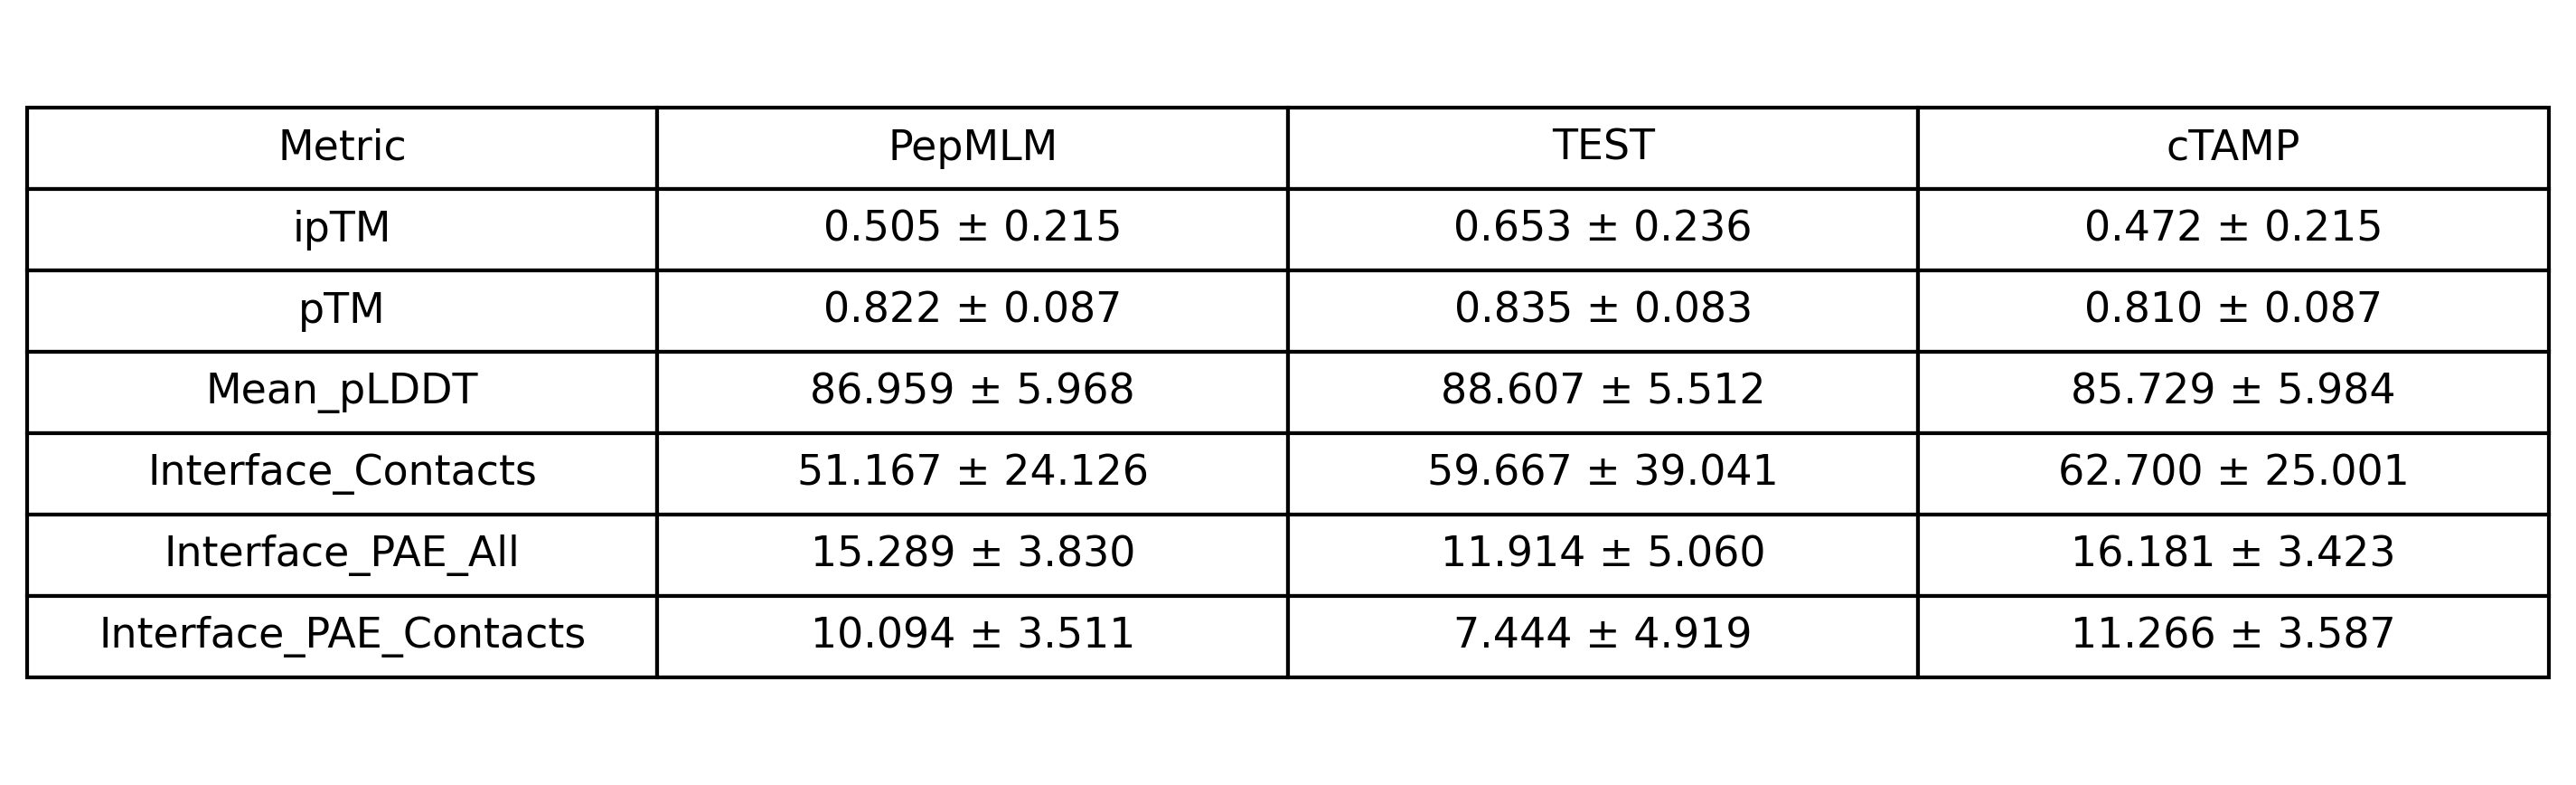

Saved:
/content/drive/MyDrive/new1/ALPHAFOLD/AlphaFold_Table.png
/content/drive/MyDrive/new1/ALPHAFOLD/AlphaFold_Table.pdf


In [4]:
import pandas as pd
import os

# ============================================================
# Paths
# ============================================================

pepmlm_file = "/content/drive/MyDrive/new1/ALPHAFOLD/PepMLM/AlphaFold_Multimer_Summary.csv"

test_file = "/content/drive/MyDrive/new1/ALPHAFOLD/TEST/AlphaFold_TEST_Summary.csv"

ctamp_file = "/content/drive/MyDrive/new1/ALPHAFOLD/cTAMP/1/AlphaFold_cTAMP_Summary.csv"


# ============================================================
# Read Summary files
# ============================================================

pepmlm = pd.read_csv(pepmlm_file, index_col=0)

test = pd.read_csv(test_file, index_col=0)

ctamp = pd.read_csv(ctamp_file, index_col=0)


# ============================================================
# Extract Mean and Std
# ============================================================

pepmlm_mean = pepmlm["Mean"]
pepmlm_std  = pepmlm["Std"]

test_mean = test["Mean"]
test_std  = test["Std"]

ctamp_mean = ctamp["Mean"]
ctamp_std  = ctamp["Std"]


# ============================================================
# Create Mean ± Std table
# ============================================================

comparison = pd.DataFrame({

    "Metric": pepmlm_mean.index,

    "PepMLM": [
        f"{m:.3f} ± {s:.3f}"
        for m, s in zip(pepmlm_mean, pepmlm_std)
    ],

    "TEST": [
        f"{m:.3f} ± {s:.3f}"
        for m, s in zip(test_mean, test_std)
    ],

    "cTAMP": [
        f"{m:.3f} ± {s:.3f}"
        for m, s in zip(ctamp_mean, ctamp_std)
    ]

})


# ============================================================
# Print
# ============================================================

print("\n========== Mean ± Std Comparison ==========")

print(comparison)


# ============================================================
# Save CSV
# ============================================================

save_path = "/content/drive/MyDrive/new1/ALPHAFOLD/AlphaFold_Mean_Std_Comparison.csv"


comparison.to_csv(
    save_path,
    index=False
)


print("\nSaved:")
print(save_path)
import matplotlib.pyplot as plt

# ============================================================
# Create high-quality table figure
# ============================================================

fig, ax = plt.subplots(figsize=(10, 3.5), dpi=300)

ax.axis("off")


table = ax.table(
    cellText=comparison.values,
    colLabels=comparison.columns,
    cellLoc="center",
    loc="center"
)


# Font size
table.auto_set_font_size(False)
table.set_fontsize(11)

# Scale table
table.scale(1.2, 1.8)


# ============================================================
# Save high-resolution outputs
# ============================================================

table_png = "/content/drive/MyDrive/new1/ALPHAFOLD/AlphaFold_Table.png"

table_pdf = "/content/drive/MyDrive/new1/ALPHAFOLD/AlphaFold_Table.pdf"


plt.savefig(
    table_png,
    dpi=600,
    bbox_inches="tight"
)


plt.savefig(
    table_pdf,
    bbox_inches="tight"
)


plt.show()


print("Saved:")
print(table_png)
print(table_pdf)


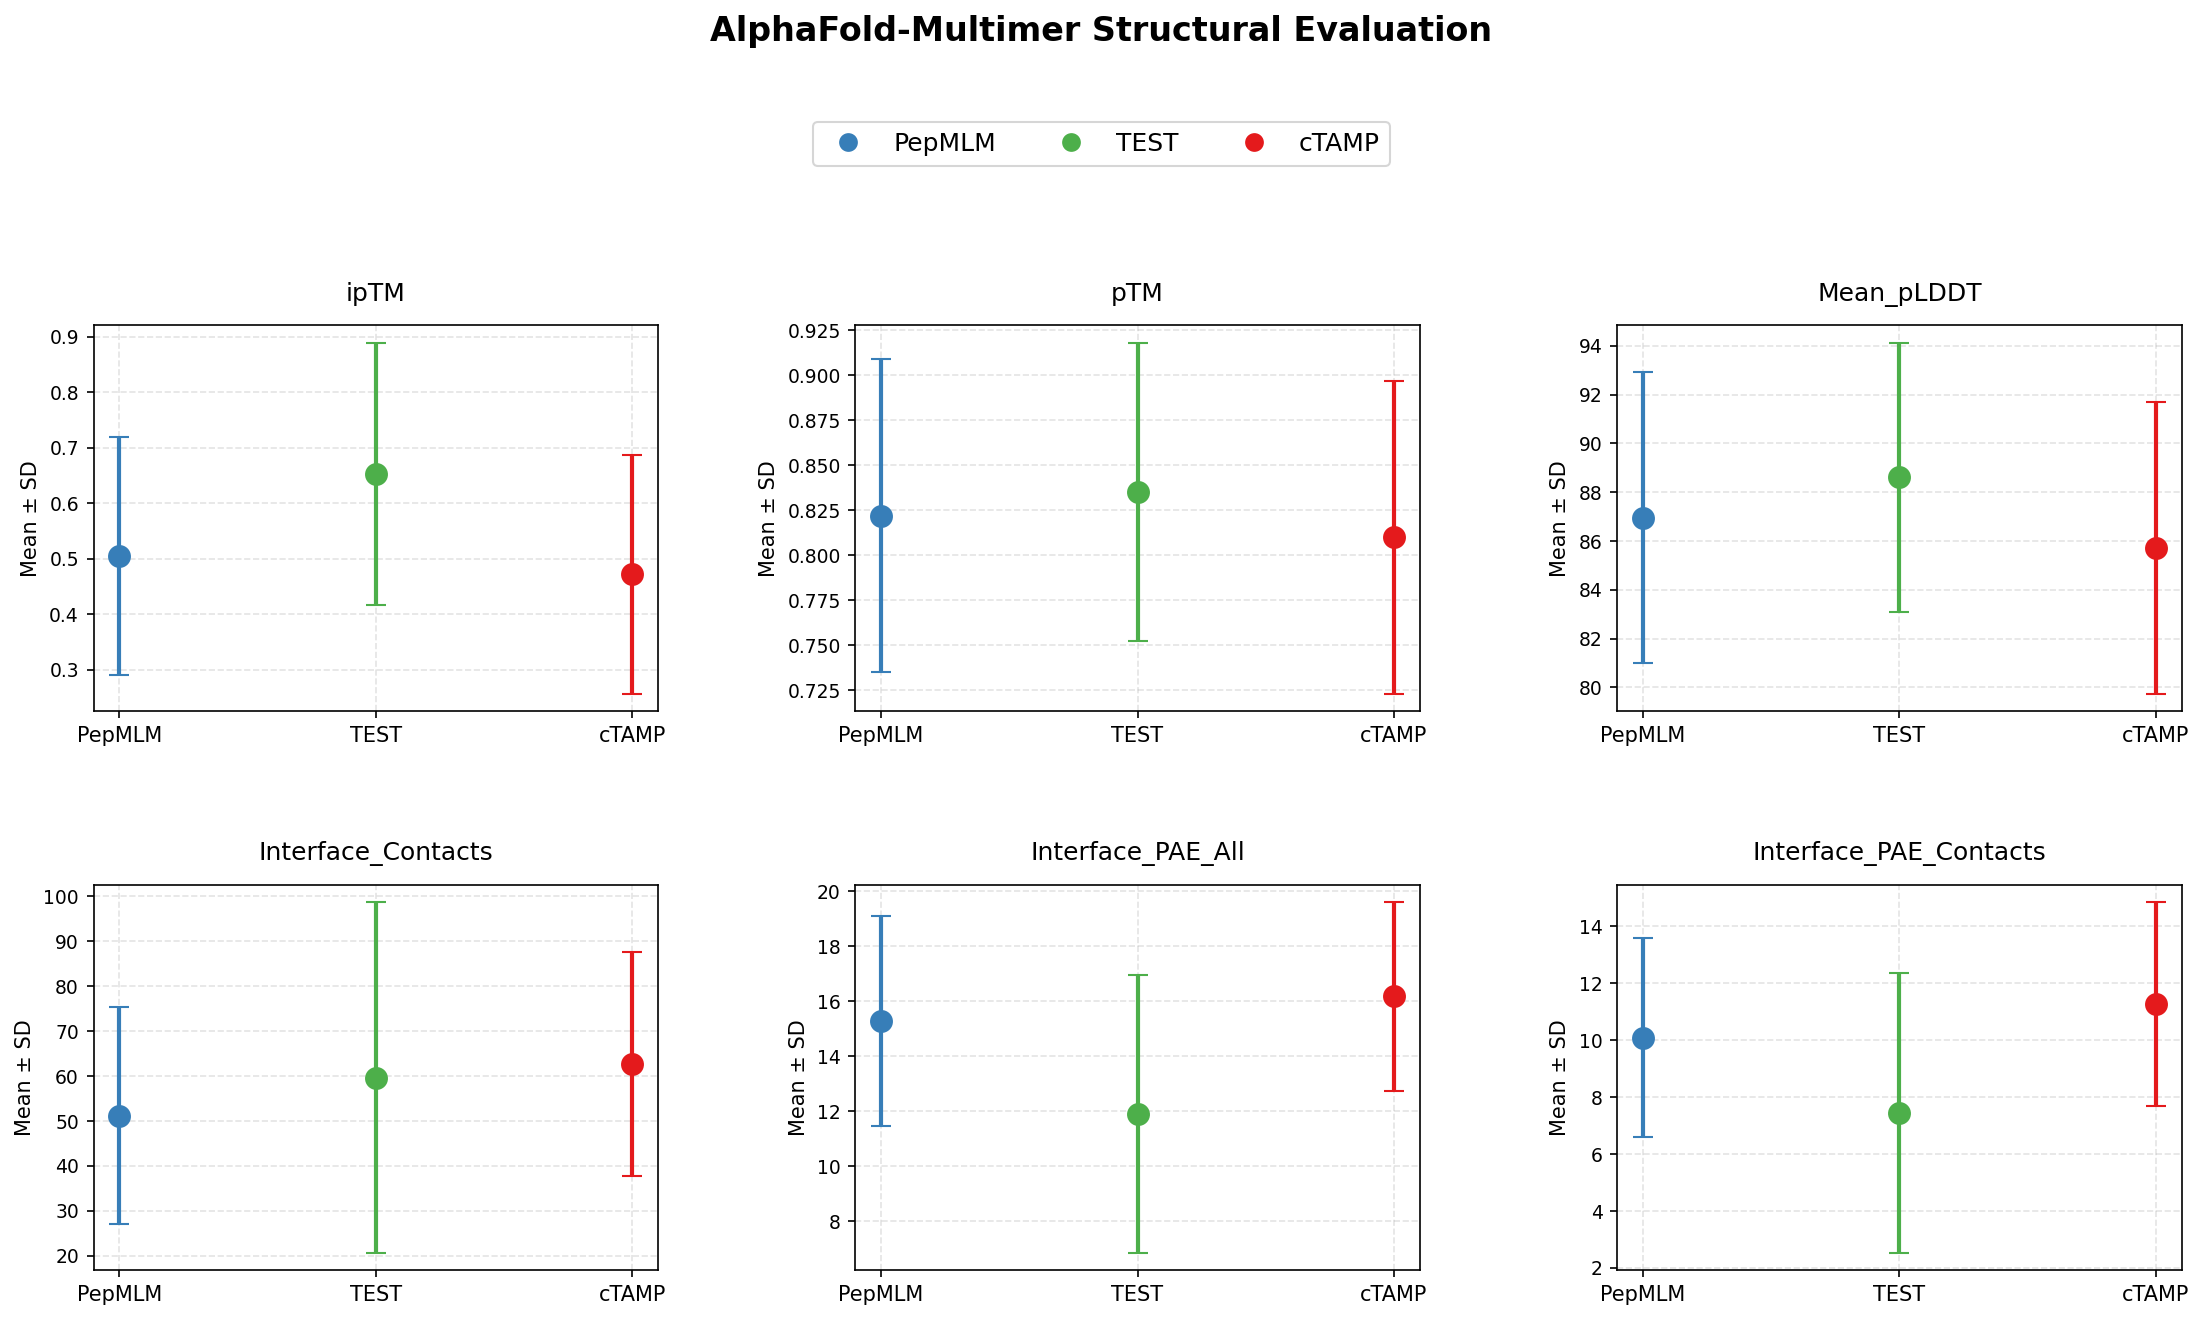

Saved:
/content/drive/MyDrive/new1/ALPHAFOLD/AlphaFold_Multimer_Comparison_Final.png
/content/drive/MyDrive/new1/ALPHAFOLD/AlphaFold_Multimer_Comparison_Final.pdf


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# Load CSV
# ============================================================

file = "/content/drive/MyDrive/new1/ALPHAFOLD/AlphaFold_Mean_Std_Comparison.csv"

df = pd.read_csv(file)


models = ["PepMLM", "TEST", "cTAMP"]


# ============================================================
# Extract Mean and Std
# ============================================================

metrics = df["Metric"].values

mean_values = {}
std_values = {}


for model in models:

    mean_values[model] = []
    std_values[model] = []

    for value in df[model]:

        mean, std = value.split(" ± ")

        mean_values[model].append(float(mean))
        std_values[model].append(float(std))


# ============================================================
# Colors
# ============================================================

colors = {
    "PepMLM": "#377eb8",
    "TEST": "#4daf4a",
    "cTAMP": "#e41a1c"
}


# ============================================================
# Figure
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16,9),
    dpi=150
)


axes = axes.flatten()

x = np.arange(len(models))


# ============================================================
# Plot
# ============================================================

for i, metric in enumerate(metrics):

    ax = axes[i]


    for j, model in enumerate(models):

        ax.errorbar(

            j,

            mean_values[model][i],

            yerr=std_values[model][i],

            fmt='o',

            markersize=10,

            capsize=5,

            linewidth=2,

            color=colors[model]

        )


    ax.set_xticks(x)

    ax.set_xticklabels(
        models,
        fontsize=10
    )


    ax.set_title(
        metric,
        fontsize=12,
        pad=12
    )


    ax.set_ylabel(
        "Mean ± SD",
        fontsize=10
    )


    ax.tick_params(
        axis='y',
        labelsize=9
    )


    ax.grid(
        linestyle="--",
        alpha=0.35
    )


# ============================================================
# Legend
# ============================================================

legend_elements = [

    plt.Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        markerfacecolor=colors["PepMLM"],
        markersize=10,
        label="PepMLM"
    ),

    plt.Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        markerfacecolor=colors["TEST"],
        markersize=10,
        label="TEST"
    ),

    plt.Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        markerfacecolor=colors["cTAMP"],
        markersize=10,
        label="cTAMP"
    )

]


fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=3,
    fontsize=12,
    bbox_to_anchor=(0.5,0.98)
)


# ============================================================
# Title
# ============================================================

fig.suptitle(
    "AlphaFold-Multimer Structural Evaluation",
    fontsize=16,
    fontweight="bold",
    y=1.05
)


# فاصله مناسب بین نمودارها
plt.subplots_adjust(
    top=0.82,
    bottom=0.12,
    left=0.08,
    right=0.95,
    hspace=0.45,
    wspace=0.35
)


# ============================================================
# Save High Quality
# ============================================================

png_path = "/content/drive/MyDrive/new1/ALPHAFOLD/AlphaFold_Multimer_Comparison_Final.png"

pdf_path = "/content/drive/MyDrive/new1/ALPHAFOLD/AlphaFold_Multimer_Comparison_Final.pdf"


plt.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight"
)


plt.savefig(
    pdf_path,
    bbox_inches="tight"
)


plt.show()


print("Saved:")
print(png_path)
print(pdf_path)